<a href="https://colab.research.google.com/github/morganhenshaw/NLSTRadiomics/blob/main/create_metadata_table.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install idc-index

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 98.7 MB/s eta 0:00:00
  Attempting uninstall: duckdb
    Found existing installation: duckdb 1.3.2
    Uninstalling duckdb-1.3.2:
      Successfully uninstalled duckdb-1.3.2


In [18]:
from idc_index import IDCClient
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
c = IDCClient()

c.fetch_index('clinical_index')

print('Columns available in clinical_index:\n' + '\n'.join(c.clinical_index.keys()))

Columns available in clinical_index:
collection_id
table_name
short_table_name
column
column_label
values


In [20]:
# Accessing clinical metadata
nlst_clinical_data_columns = c.clinical_index[c.clinical_index['collection_id'] == 'nlst']
nlst_clinical_data_columns[['short_table_name', 'column', 'column_label', 'values']]

,short_table_name,column,column_label,values
7184,nlst_canc,dicom_patient_id,idc_provenance_dicom_patient_id,[]
7185,nlst_canc,source_batch,idc_provenance_source_batch,"[{'option_code': '0', 'option_description': No..."
7186,nlst_canc,pid,pid,[]
7187,nlst_canc,lc_topog,ICD-O-3 Topography: ICD-O-3 topography of lung...,"[{'option_code': 'C34.0', 'option_description'..."
7188,nlst_canc,topog_source,Source of samples for ICD-O-3 code: Indicates ...,"[{'option_code': '.M', 'option_description': '..."
...,...,...,...,...
7304,nlst_screen,ctdxqual_graininess,Reason for limited / non-diagnostic CT: Excess...,"[{'option_code': '.N', 'option_description': '..."
7305,nlst_screen,ctdxqual_other,Reason for limited / non-diagnostic CT: Other ...,"[{'option_code': '.N', 'option_description': '..."
7306,nlst_screen,ct_recon_filter3,CT reconstruction algorithm / filter: What CT ...,"[{'option_code': '.M', 'option_description': '..."
7307,nlst_screen,ct_recon_filter4,CT reconstruction algorithm / filter: What CT ...,"[{'option_code': '.M', 'option_description': '..."


In [21]:
# Search column names and labels keywords to identify metadata of interest
stage_columns = nlst_clinical_data_columns[nlst_clinical_data_columns['column_label'].str.contains('stage', case=False, na=False)]
stage_columns

,collection_id,table_name,short_table_name,column,column_label,values
7191,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,de_stag,"Stage (""Best"": Path if avail., else Clin): Lun...","[{'option_code': '.M', 'option_description': '..."
7192,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,path_stag,Pathologic Stage: Pathologic stage of lung can...,"[{'option_code': '.M', 'option_description': '..."
7193,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,clinical_stag,Clinical Stage: Clinical stage of lung cancer ...,"[{'option_code': '.M', 'option_description': '..."
7194,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,stage_sum,Summary staging: Summary staging.For all ACRIN...,"[{'option_code': '.M', 'option_description': '..."
7195,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,valcsg,VALCSG Stage (Small cell only): VALCSG staging...,"[{'option_code': '.M', 'option_description': '..."
7202,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,de_stag_7thed,AJCC 7th edition stage: Stage of first primary...,"[{'option_code': '.M', 'option_description': '..."
7208,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,source_best_stage,"Source of ""best"" stage (de_stag): Describes wh...","[{'option_code': '1', 'option_description': 'P..."
7215,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,stage_only,"Stage Only (if separate T, N, & M not availabl...","[{'option_code': '.M', 'option_description': '..."
7269,nlst,bigquery-public-data.idc_v23_clinical.nlst_prsn,nlst_prsn,de_stag,"Lung cancer Stage: Lung cancer stage (AJCC 6),...","[{'option_code': '.M', 'option_description': '..."
7286,nlst,bigquery-public-data.idc_v23_clinical.nlst_prsn,nlst_prsn,de_stag_7thed,AJCC 7th edition stage: Stage of first primary...,"[{'option_code': '.M', 'option_description': '..."


In [22]:
# Access nlst_canc table
nlst_canc_df = c.get_clinical_table("nlst_canc")
nlst_canc_df

,dicom_patient_id,source_batch,pid,lc_topog,topog_source,de_type,de_grade,de_stag,path_stag,clinical_stag,...,path_t,clinical_n,path_n,clinical_m,path_m,stage_only,study_yr,dataset_version,lc_order,candx_days
0,102266,0,102266,C34.1,,8046,4,110,,,...,,,,,,110,0,2011.02.03/05.12.21,1,69
1,118193,0,118193,C34.9,4,,1,888,,,...,,,,,,888,0,2011.02.03/05.12.21,1,128
2,119813,0,119813,C34.9,1,8046,8,888,,,...,,,,,,888,0,2011.02.03/05.12.21,1,18
3,125998,0,125998,C34.2,2,8046,8,,,,...,,,,,,,0,2011.02.03/05.12.21,1,212
4,102161,0,102161,C34.1,,8013,4,110,110,,...,100,,0,,0,110,0,2011.02.03/05.12.21,1,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2145,210195,0,210195,C34.2,1,8070,4,900,999,999,...,999,0,,0,,,5,2011.02.03/05.12.21,2,1957
2146,210218,0,210218,C34.2,,8240,9,999,999,999,...,999,999,999,999,999,,2,2011.02.03/05.12.21,1,1024
2147,213639,0,213639,C34.3,3,8046,4,400,999,999,...,999,200,999,0,999,400,1,2011.02.03/05.12.21,1,721
2148,214850,0,214850,C34.8,2,8041,5,999,999,999,...,999,100,999,0,999,,4,2011.02.03/05.12.21,1,1751


In [23]:
# What are values of attribute clinical_stag?
print(nlst_canc_df['clinical_stag'].unique())

# Make them human readable
clinical_stag_values = nlst_clinical_data_columns[nlst_clinical_data_columns['column']=='clinical_stag']['values'].values[0]
print(clinical_stag_values)

['' '110' '120' '210' '220' '310' '320' '400' '888' '900' '994' '999']
[{'option_code': '.M', 'option_description': 'Missing'}
 {'option_code': '110', 'option_description': 'Stage IA'}
 {'option_code': '120', 'option_description': 'Stage IB'}
 {'option_code': '210', 'option_description': 'Stage IIA'}
 {'option_code': '220', 'option_description': 'Stage IIB'}
 {'option_code': '310', 'option_description': 'Stage IIIA'}
 {'option_code': '320', 'option_description': 'Stage IIIB'}
 {'option_code': '400', 'option_description': 'Stage IV'}
 {'option_code': '888', 'option_description': 'TNM not available'}
 {'option_code': '900', 'option_description': 'Occult Carcinoma'}
 {'option_code': '994', 'option_description': 'Carcinoid, cannot be assessed'}
 {'option_code': '999', 'option_description': 'Unknown, cannot be assessed'}]


In [24]:
# First, create a dictionary from the array of dictionaries
mapping_dict = {item['option_code']: item['option_description'] for item in clinical_stag_values}

# Create the new column 'X_descriptions' using map function
nlst_canc_df['clinical_stag_meaning'] = nlst_canc_df['clinical_stag'].astype(str).map(mapping_dict)

In [25]:
# drop cases that don't have images
with_images = pd.merge(c.index[c.index['Modality'] == 'CT'][['PatientID']].drop_duplicates(), nlst_canc_df, left_on='PatientID', right_on='dicom_patient_id', how='inner')

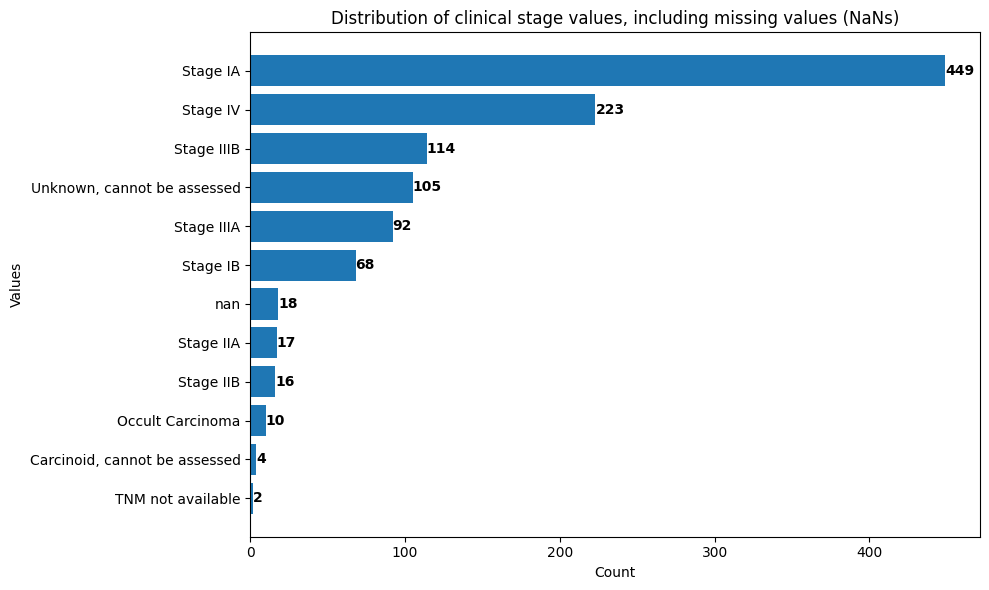

In [26]:
# plot histogram of values in nlst_clinical_df['clinical_stag_meaning'] by count,
# including NaN as a separate item

# Assuming your DataFrame is named 'df' and the column is named 'column_name'

# Count values including NaNs
value_counts = with_images['clinical_stag_meaning'].value_counts(dropna=False)

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(value_counts.index.astype(str), value_counts.values)

# Add labels to the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width}',
            ha='left', va='center', fontweight='bold')

# Customize the plot
plt.title('Distribution of clinical stage values, including missing values (NaNs)')
plt.xlabel('Count')
plt.ylabel('Values')

# Adjust layout and display the plot
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

In [27]:
print(f'Attributes in IDC index: \n{c.index.dtypes}\n')

Attributes in IDC index: 
collection_id             object
analysis_result_id        object
PatientID                 object
SeriesInstanceUID         object
StudyInstanceUID          object
source_DOI                object
PatientAge                object
PatientSex                object
StudyDate                 object
StudyDescription          object
BodyPartExamined          object
Modality                  object
Manufacturer              object
ManufacturerModelName     object
SeriesDate                object
SeriesDescription         object
SeriesNumber              object
instanceCount              Int64
license_short_name        object
aws_bucket                object
crdc_series_uuid          object
series_aws_url            object
series_size_MB           float64
dtype: object



In [28]:
patient_ages = c.index[c.index['collection_id']=='nlst'][['PatientAge']].value_counts()
print(patient_ages)

PatientAge
068Y          99
059Y          88
064Y          87
065Y          80
058Y          72
061Y          68
060Y          68
067Y          67
063Y          66
062Y          64
056Y          62
073Y          60
072Y          57
070Y          56
066Y          55
069Y          54
057Y          49
055Y          44
071Y          37
074Y          26
Name: count, dtype: int64


In [29]:
my_ProjectID = "nlst-radiomics"

import os
os.environ["GCP_PROJECT_ID"] = my_ProjectID

from google.colab import auth
auth.authenticate_user()

In [30]:
%%bigquery --project=$my_ProjectID

SELECT COUNT(DISTINCT(collection_id)) as collections_cnt
FROM bigquery-public-data.idc_current.dicom_all

Query is running:   0%|          |

Downloading:   0%|          |

,collections_cnt
0,161


In [31]:
from google.cloud import bigquery

bq_client = bigquery.Client(my_ProjectID)

selection_query = """
SELECT DISTINCT Manufacturer, ManufacturerModelName
FROM bigquery-public-data.idc_current.dicom_all
WHERE collection_id = 'nlst' AND Modality = 'CT'
"""

selection_result = bq_client.query(selection_query)
selection_df = selection_result.result().to_dataframe()

selection_df

,Manufacturer,ManufacturerModelName
0,GE MEDICAL S]STEMS,LightSpeed QX/i
1,TOSHIBA,Aquilion
2,SIEMENS,Sensation 4
3,GE MEDICAL SYSTEMS,LightSpeed VCT
4,GE MEDICAL SYSTEMS,LightSpeed Power
5,Philips,Mx8000 IDT 16
6,SIEMENS,Sensation 16
7,GE MEDICAL SYSTEMS,LightSpeed Plus
8,Philips,Mx8000 IDT
9,SIEMENS,Sensation 10


In [32]:
selection_query = """
SELECT
  COUNT(DISTINCT PatientID) AS num_patients,
  COUNT(DISTINCT StudyInstanceUID) AS num_studies,
  COUNT(DISTINCT SeriesInstanceUID) AS num_series,
FROM bigquery-public-data.idc_current.dicom_all
WHERE collection_id = 'nlst'
"""

selection_result = bq_client.query(selection_query)
selection_df = selection_result.result().to_dataframe()

selection_df

,num_patients,num_studies,num_series
0,26410,73574,590572


In [33]:
selection_query = """
SELECT
  COUNT(DISTINCT PatientSex) AS num_sex,
  COUNT(DISTINCT PatientAge) AS num_age,
  COUNT(DISTINCT EthnicGroup) AS num_ethnic_groups,
  COUNT(DISTINCT PatientWeight) AS num_weight,
  COUNT(DISTINCT InstitutionName) AS num_imaging_centers,
  COUNT(DISTINCT InstitutionAddress) AS num_imaging_center_addresses,
  COUNT(DISTINCT ClinicalTrialCoordinatingCenterName) AS num_clinical_trial_centers
FROM bigquery-public-data.idc_current.dicom_all
WHERE collection_id = 'nlst'
"""

selection_result = bq_client.query(selection_query)
selection_df = selection_result.result().to_dataframe()

selection_df

,num_sex,num_age,num_ethnic_groups,num_weight,num_imaging_centers,num_imaging_center_addresses,num_clinical_trial_centers
0,2,20,6,0,0,0,2


In [34]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Task
Construct a BigQuery SQL query to extract patient and series-level metadata for NLST CT scans from `bigquery-public-data.idc_current.dicom_all`. The query should include `PatientID`, `SeriesInstanceUID`, parsed `PatientAge`, `PatientSex`, `EthnicGroup`, `Manufacturer`, `ManufacturerModelName`, `ContrastBolusAgent`, `InstitutionName`, `KVP`, `XRayTubeCurrent`, `Exposure`, `ExposureTime`, `RadiationDoseCT`, `DicomPixelSpacing`, `SliceThickness`, and `ReconstructionDiameter`. Filter the results for `collection_id = 'nlst'` and `Modality = 'CT'`, ensuring each row corresponds to a unique series, and then load the query results into a Pandas DataFrame. Finally, display the first few rows and the shape of the DataFrame, along with a note about the lack of direct image-derived radiomics features and the potential need for `EthnicGroup` cleaning.

## construct_bigquery_cohort_query

### Subtask:
Construct a BigQuery SQL query to select patient and series-level metadata for NLST CT scans, including patient ID, series ID, parsed age, sex, ethnic group, manufacturer, model, contrast agent, imaging center, and other key acquisition parameters from the `bigquery-public-data.idc_current.dicom_all` table, filtered for NLST collection and CT modality. The query will aim for one row per series.


**Reasoning**:
The subtask requires constructing a BigQuery SQL query with specific selections, parsing of `PatientAge`, and filtering for NLST CT scans, grouped to ensure one row per series. This code block will define the SQL query string.



In [14]:
non_null_counts_query = """
SELECT
  COUNT(DISTINCT PatientID) AS total_patients,
  COUNT(PatientAge) AS non_null_patient_age,
  COUNT(PatientSex) AS non_null_patient_sex
FROM `bigquery-public-data.idc_current.dicom_all`
WHERE
  collection_id = 'nlst'
  AND Modality = 'CT'
"""

non_null_counts_result = bq_client.query(non_null_counts_query)
non_null_counts_df = non_null_counts_result.result().to_dataframe()

print('Non-null counts for Age and Sex in NLST CT data:')
display(non_null_counts_df)

Non-null counts for Age and Sex in NLST CT data:


,total_patients,non_null_patient_age,non_null_patient_sex
0,26254,0,0


In [42]:
patient_cohort_query = """
SELECT
  p.pid AS PatientID,
  p.age AS PatientAge_Years,
  p.gender AS PatientSex,
  p.race AS Race,
  p.cigsmok AS CigaretteSmokingStatus,
  ANY_VALUE(c.de_stag) AS LungCancerStage
FROM `bigquery-public-data.idc_v23_clinical.nlst_prsn` AS p
LEFT JOIN `bigquery-public-data.idc_v23_clinical.nlst_canc` AS c
  ON p.pid = c.pid
JOIN (
  SELECT
    PatientID
  FROM `bigquery-public-data.idc_current.dicom_all`
  WHERE
    collection_id = 'nlst'
    AND Modality = 'CT'
  GROUP BY PatientID
) AS d_filter
ON CAST(p.pid AS STRING) = d_filter.PatientID
GROUP BY
  p.pid,
  p.age,
  p.gender,
  p.race,
  p.cigsmok
"""

patient_cohort_result = bq_client.query(patient_cohort_query)
patient_cohort = patient_cohort_result.result().to_dataframe()

print('First 5 rows of the new patient cohort DataFrame:')
display(patient_cohort.head())
print(f'\nShape of the new patient cohort DataFrame: {patient_cohort.shape}')

First 5 rows of the new patient cohort DataFrame:


,PatientID,PatientAge_Years,PatientSex,Race,CigaretteSmokingStatus,LungCancerStage
0,213651,54,2,1,1,None
1,208752,43,1,2,1,None
2,208329,75,2,1,0,None
3,101237,55,2,1,1,None
4,101445,55,2,1,0,None



Shape of the new patient cohort DataFrame: (26254, 6)


In [39]:
print('--- Contents of idc_v23_clinical.nlst_canc table ---\n')
nlst_canc_info = c.clinical_index[c.clinical_index['short_table_name'] == 'nlst_canc'][['column', 'column_label', 'values']]
display(nlst_canc_info.head(10))
print('\n') # Add a newline for better readability

--- Contents of idc_v23_clinical.nlst_canc table ---



,column,column_label,values
7184,dicom_patient_id,idc_provenance_dicom_patient_id,[]
7185,source_batch,idc_provenance_source_batch,"[{'option_code': '0', 'option_description': None}]"
7186,pid,pid,[]
7187,lc_topog,ICD-O-3 Topography: ICD-O-3 topography of lung cancer.,"[{'option_code': 'C34.0', 'option_description': None}, {'option_code': 'C34.1', 'option_description': None}, {'option_code': 'C34.2', 'option_description': None}, {'option_code': 'C34.3', 'option_description': None}, {'option_code': 'C34.8', 'option_description': None}, {'option_code': 'C34.9', 'option_description': None}, {'option_code': 'C38.3', 'option_description': None}]"
7188,topog_source,Source of samples for ICD-O-3 code: Indicates the source of information used to determine the ICD-O-3 code.,"[{'option_code': '.M', 'option_description': 'Missing'}, {'option_code': '1', 'option_description': 'Cytology'}, {'option_code': '2', 'option_description': 'Histology'}, {'option_code': '3', 'option_description': 'Combined'}, {'option_code': '4', 'option_description': 'Clinical (LSS only)'}]"
7189,de_type,"ICD-O-3 Morphology (from histology): Lung cancer type from ICD-O-3 morphology. For LSS participants, this is recorded separately from the complete ICD code, and represents the best information available on the type of the cancer.","[{'option_code': '.M', 'option_description': 'Missing'}]"
7190,de_grade,"Lung Cancer Grade: Lung cancer grade. For ACRIN, this is the ICD-O-3 grade. For LSS, this comes from a separate question on the DE form.","[{'option_code': '1', 'option_description': 'Grade Cannot be Assessed'}, {'option_code': '2', 'option_description': 'Well Differentiated (G1)'}, {'option_code': '3', 'option_description': 'Moderately Differentiated (G2)'}, {'option_code': '4', 'option_description': 'Poorly Differentiated (G3)'}, {'option_code': '5', 'option_description': 'Undifferentiated (G4)'}, {'option_code': '6', 'option_description': 'Unspecified in Pathology Report'}, {'option_code': '8', 'option_description': 'Unknown'}, {'option_code': '9', 'option_description': 'Missing'}]"
7191,de_stag,"Stage (""Best"": Path if avail., else Clin): Lung cancer stage (AJCC 6), combining clinical and pathologic staging information.","[{'option_code': '.M', 'option_description': 'Missing'}, {'option_code': '110', 'option_description': 'Stage IA'}, {'option_code': '120', 'option_description': 'Stage IB'}, {'option_code': '210', 'option_description': 'Stage IIA'}, {'option_code': '220', 'option_description': 'Stage IIB'}, {'option_code': '310', 'option_description': 'Stage IIIA'}, {'option_code': '320', 'option_description': 'Stage IIIB'}, {'option_code': '400', 'option_description': 'Stage IV'}, {'option_code': '888', 'option_description': 'TNM not available'}, {'option_code': '900', 'option_description': 'Occult Carcinoma'}, {'option_code': '994', 'option_description': 'Carcinoid, cannot be assessed'}, {'option_code': '999', 'option_description': 'Unknown, cannot be assessed'}]"
7192,path_stag,Pathologic Stage: Pathologic stage of lung cancer (AJCC 6).,"[{'option_code': '.M', 'option_description': 'Missing'}, {'option_code': '110', 'option_description': 'Stage IA'}, {'option_code': '120', 'option_description': 'Stage IB'}, {'option_code': '210', 'option_description': 'Stage IIA'}, {'option_code': '220', 'option_description': 'Stage IIB'}, {'option_code': '310', 'option_description': 'Stage IIIA'}, {'option_code': '320', 'option_description': 'Stage IIIB'}, {'option_code': '400', 'option_description': 'Stage IV'}, {'option_code': '888', 'option_description': 'TNM not available'}, {'option_code': '900', 'option_description': 'Occult Carcinoma'}, {'option_code': '994', 'option_description': 'Carcinoid, cannot be assessed'}, {'option_code': '999', 'option_description': 'Unknown, cannot be assessed'}]"
7193,clinical_stag,Clinical Stage: Clinical stage of lung cancer (AJCC 6).,"[{'option_code': '.M', 'option_description': 'Missing'}, {'option_code': '110', 'option_description':

In [61]:
# Get mapping for PatientSex from nlst_prsn_info
sex_mapping = {item['option_code']: item['option_description'] for item in nlst_prsn_info[nlst_prsn_info['column']=='gender']['values'].iloc[0] if item['option_code'] != '.M'}
patient_cohort['PatientSex_mapped'] = patient_cohort['PatientSex'].astype(str).map(sex_mapping).fillna('Missing')

# Get mapping for Race from nlst_prsn_info
race_mapping = {item['option_code']: item['option_description'] for item in nlst_prsn_info[nlst_prsn_info['column']=='race']['values'].iloc[0] if item['option_code'] != '.M'}
patient_cohort['Race_mapped'] = patient_cohort['Race'].astype(str).map(race_mapping).fillna('Missing')

# Get mapping for CigaretteSmokingStatus from nlst_prsn_info
smoking_mapping = {item['option_code']: item['option_description'] for item in nlst_prsn_info[nlst_prsn_info['column']=='cigsmok']['values'].iloc[0] if item['option_code'] != '.M'}
patient_cohort['CigaretteSmokingStatus_mapped'] = patient_cohort['CigaretteSmokingStatus'].astype(str).map(smoking_mapping).fillna('Missing')

# LungCancerStage mapping (already available as mapping_dict)
patient_cohort['LungCancerStage_mapped'] = patient_cohort['LungCancerStage'].astype(str).map(mapping_dict).fillna('Missing')

print("Coded values have been mapped to human-readable descriptions.")

Coded values have been mapped to human-readable descriptions.


In [62]:
import numpy as np

# 1. Define Age Groups
bins = [-np.inf, 55, 60, 65, 70, 75, np.inf]
labels = ['<55 years', '55-59 years', '60-64 years', '65-69 years', '70-74 years', '>=75 years']
patient_cohort['AgeGroup'] = pd.cut(patient_cohort['PatientAge_Years'], bins=bins, labels=labels, right=False)

# Function to calculate counts and percentages for a given column
def get_summary_stats(df, column_name, category_label):
    counts = df[column_name].value_counts(dropna=False)
    percentages = (counts / len(df)) * 100
    summary_df = pd.DataFrame({
        'Characteristic': counts.index,
        'Count': counts.values,
        'Percentage': percentages.values
    })
    summary_df['Category'] = category_label
    return summary_df[['Category', 'Characteristic', 'Count', 'Percentage']]

# Get summary statistics for each column
age_summary = get_summary_stats(patient_cohort, 'AgeGroup', 'Age')
sex_summary = get_summary_stats(patient_cohort, 'PatientSex_mapped', 'Sex')
race_summary = get_summary_stats(patient_cohort, 'Race_mapped', 'Race/Ethnicity')
smoking_summary = get_summary_stats(patient_cohort, 'CigaretteSmokingStatus_mapped', 'Cigarette Smoking Status')
stage_summary = get_summary_stats(patient_cohort, 'LungCancerStage_mapped', 'Lung Cancer Stage')

# Combine all summaries into a single DataFrame
table1_summary = pd.concat([
    age_summary,
    sex_summary,
    race_summary,
    smoking_summary,
    stage_summary
])

# Format percentages for display
table1_summary['Percentage'] = table1_summary['Percentage'].map('{:.2f}%'.format)

print('Table 1-like Summary Statistics:')
display(table1_summary)

Table 1-like Summary Statistics:


,Category,Characteristic,Count,Percentage
0,Age,55-59 years,11215,42.72%
1,Age,60-64 years,8033,30.60%
2,Age,65-69 years,4691,17.87%
3,Age,70-74 years,2312,8.81%
4,Age,<55 years,2,0.01%
5,Age,>=75 years,1,0.00%
0,Sex,Male,15512,59.08%
1,Sex,Female,10742,40.92%
0,Race/Ethnicity,White,23969,91.30%
1,Race/Ethnicity,Black or African-American,1135,4.32%


In [40]:
print('--- Contents of idc_v23_clinical.nlst_prsn table ---\n')
nlst_prsn_info = c.clinical_index[c.clinical_index['short_table_name'] == 'nlst_prsn'][['column', 'column_label', 'values']]
display(nlst_prsn_info.head(10))
print('\n') # Add a newline for better readability

--- Contents of idc_v23_clinical.nlst_prsn table ---



,column,column_label,values
7246,dicom_patient_id,idc_provenance_dicom_patient_id,[]
7247,source_batch,idc_provenance_source_batch,"[{'option_code': '0', 'option_description': None}]"
7248,race,Race,"[{'option_code': '1', 'option_description': 'White'}, {'option_code': '2', 'option_description': 'Black or African-American'}, {'option_code': '3', 'option_description': 'Asian'}, {'option_code': '4', 'option_description': 'American Indian or Alaskan Native'}, {'option_code': '5', 'option_description': 'Native Hawaiian or Other Pacific Islander'}, {'option_code': '6', 'option_description': 'More than one race'}, {'option_code': '7', 'option_description': 'Participant refused to answer'}, {'option_code': '95', 'option_description': 'Missing data form - form is not expected to ever be completed'}, {'option_code': '96', 'option_description': 'Missing - no response'}, {'option_code': '98', 'option_description': 'Missing - form was submitted and the answer was left blank'}, {'option_code': '99', 'option_description': 'Unknown/ decline to answer'}]"
7249,cigsmok,Smoking status at T0: Cigarette smoking status (current vs former) at randomization. Former smokers must have quit within 15 years of eligibility determination to have been eligible for the trial.,"[{'option_code': '0', 'option_description': 'Former'}, {'option_code': '1', 'option_description': 'Current'}]"
7250,gender,Gender,"[{'option_code': '1', 'option_description': 'Male'}, {'option_code': '2', 'option_description': 'Female'}]"
7251,age,Age at randomization (in years; whole number),[]
7252,loclhil,Cancer in Left Hilum: Was the primary tumor located in the left hilum? A tumor may be located in more than one location.,"[{'option_code': '.N', 'option_description': 'Not Applicable'}, {'option_code': '0', 'option_description': 'No'}, {'option_code': '1', 'option_description': 'Yes'}]"
7253,locllow,Cancer in Left lower lobe: Was the primary tumor located in the left lower lobe? A tumor may be located in more than one location.,"[{'option_code': '.N', 'option_description': 'Not Applicable'}, {'option_code': '0', 'option_description': 'No'}, {'option_code': '1', 'option_description': 'Yes'}]"
7254,loclup,Cancer in Left upper lobe: Was the primary tumor located in the left upper lobe? A tumor may be located in more than one location.,"[{'option_code': '.N', 'option_description': 'Not Applicable'}, {'option_code': '0', 'option_description': 'No'}, {'option_code': '1', 'option_description': 'Yes'}]"
7255,locrhil,Cancer in Right Hilum: Was the primary tumor located in the right hilum? A tumor may be located in more than one location.,"[{'option_code': '.N', 'option_description': 'Not Applicable'}, {'option_code': '0', 'option_description': 'No'}, {'option_code': '1', 'option_description': 'Yes'}]"


In [41]:
print('--- Contents of idc_v23_clinical.nlst_screen table ---\n')
nlst_screen_info = c.clinical_index[c.clinical_index['short_table_name'] == 'nlst_screen'][['column', 'column_label', 'values']]
display(nlst_screen_info.head(10))

--- Contents of idc_v23_clinical.nlst_screen table ---



,column,column_label,values
7287,dicom_patient_id,idc_provenance_dicom_patient_id,[]
7288,source_batch,idc_provenance_source_batch,"[{'option_code': '0', 'option_description': None}]"
7289,pid,pid,[]
7290,ctdxqual,Overall diagnostic quality of CT examination,"[{'option_code': '.M', 'option_description': 'Missing'}, {'option_code': '1', 'option_description': 'Diagnostic CT'}, {'option_code': '2', 'option_description': 'Limited CT, but interpretable'}, {'option_code': '3', 'option_description': 'Non-diagnostic CT exam'}]"
7291,study_yr,Study Year of Screen,"[{'option_code': '0', 'option_description': 'T0'}, {'option_code': '1', 'option_description': 'T1'}, {'option_code': '2', 'option_description': 'T2'}]"
7292,techpara_kvp,Technical parameters: kVp: Technical parameters: kVpThis variable comes from the data collection forms. It may disagree with data extracted from the CT images' DICOM headers. Header data may be obtained from the NLST CT image collection at TCIA or from ACRIN.,"[{'option_code': '.M', 'option_description': 'Missing'}]"
7293,techpara_ma,Technical parameters: mA: Technical parameters: mAThis variable comes from the data collection forms. It may disagree with data extracted from the CT images' DICOM headers. Header data may be obtained from the NLST CT image collection at TCIA or from ACRIN.,"[{'option_code': '.M', 'option_description': 'Missing'}]"
7294,techpara_fov,Technical parameters: Display FOV in cm: Technical parameters: Display FOV in cmThis variable comes from the data collection forms. It may disagree with data extracted from the CT images' DICOM headers. Header data may be obtained from the NLST CT image collection at TCIA or from ACRIN.,"[{'option_code': '.M', 'option_description': 'Missing'}]"
7295,techpara_effmas,Technical parameters: Effective mAs: Technical parameters: Effective mAsThis variable comes from the data collection forms. It may disagree with data extracted from the CT images' DICOM headers. Header data may be obtained from the NLST CT image collection at TCIA or from ACRIN.,"[{'option_code': '.M', 'option_description': 'Missing'}]"
7296,ct_recon_filter1,CT reconstruction algorithm / filter: What CT reconstruction algorithm / filter was used for the screen?These variables come from the data collection forms. They may disagree with data extracted from the CT images' DICOM headers. Header data may be obtained from the NLST CT image collection at TCIA or from ACRIN.,"[{'option_code': '.M', 'option_description': 'Missing or less than 4 algorithms/filters'}, {'option_code': '1', 'option_description': 'GE Bone'}, {'option_code': '2', 'option_description': 'GE Standard'}, {'option_code': '3', 'option_description': 'GE, other'}, {'option_code': '4', 'option_description': 'Phillips D'}, {'option_code': '5', 'option_description': 'Phillips C'}, {'option_code': '6', 'option_description': 'Phillips, other'}, {'option_code': '7', 'option_description': 'Siemens B50F'}, {'option_code': '8', 'option_description': 'Siemens B30'}, {'option_code': '9', 'option_description': 'Siemens, other'}, {'option_code': '10', 'option_description': 'Toshiba FC10'}, {'option_code': '11', 'option_description': 'Toshiba FC51'}, {'option_code': '12', 'option_description': 'Toshiba, other'}]"


### Explanation of NLST Clinical Tables:

*   **`nlst_canc` (National Lung Screening Trial Cancer Data)**: This table contains detailed information related to diagnosed lung cancers within the NLST cohort. It includes fields such as `lc_topog` (ICD-O-3 Topography of lung cancer), `de_stag` (overall stage of lung cancer), `path_stag` (pathologic stage), `clinical_stag` (clinical stage), `de_grade` (tumor grade), and various T, N, M staging components. It also contains `candx_days` (days to cancer diagnosis) and `dataset_version`.

*   **`nlst_prsn` (National Lung Screening Trial Person Data)**: This table provides patient-level demographic and baseline information for individuals enrolled in the NLST study. Key columns include `pid` (patient ID), `age` (patient age), `gender`, `educat` (education level), `famhx_lu` (family history of lung cancer), `bmi_cat` (BMI category), `race` (race/ethnicity), and `smk_cat` (smoking category). This table serves as a central hub for patient characteristics.

*   **`nlst_screen` (National Lung Screening Trial Screening Data)**: This table focuses on the details of the screening exams performed as part of the NLST. It likely contains information related to the screening rounds, imaging findings, and diagnostic assessments. Columns include `ctdxqual_graininess` (CT image quality: graininess), `ctdxqual_other` (CT image quality: other reasons for limited diagnostic quality), `ct_recon_filter3/4` (CT reconstruction algorithm/filter details), and `dataset_version`. It also has details regarding `screen_num` (screening number), `exam_date` and `ct_dose` (CT radiation dose).